# Problem 3 - Impact of Noise on Dynamic Long-Range CNOT

This notebook builds the same long-range CNOT circuits used in `p2_and_3_modified.ipynb`:

- `qc_dyn`: dynamic long-range CNOT (LRCX) with mid-circuit measurements and feed-forward.
- `qc_uni`: unitary SWAP-chain baseline.

The simulator noise model follows the style of Problem 1: explicit Aer `NoiseModel` parameters for depolarizing gate noise, symmetric readout error, and thermal relaxation (`T1/T2`) noise. The sweep functions scan both distance `n` and one selected noise parameter.

In [26]:
from __future__ import annotations

from dataclasses import asdict, dataclass, replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.classical import expr
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

GLOBAL_SEED = 1557
SHOTS = 512
DISTANCE_DEMO = 6

np.random.seed(GLOBAL_SEED)

## 1. Long-range CNOT circuits

`distance` is the number of intermediate ancilla qubits between the control and target. The two endpoint qubits are always `q[0]` and `q[n+1]`.

In [27]:
def check_even(n: int) -> int:
    return 1 if n % 2 == 0 else 2


def initialize_circuit(distance: int) -> QuantumCircuit:
    if distance < 0:
        raise ValueError("distance must be non-negative")

    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    k = n // 2
    allcr = [cr]
    if distance > 1:
        allcr.append(ClassicalRegister(k, name="c1"))
    if distance > 0:
        allcr.append(ClassicalRegister(n - k, name="c2"))

    qc = QuantumCircuit(qr, *allcr, name="LRCX_dynamic")
    qc.h(0)  # Prepare the input |+>|0> used for CNOT certification.
    return qc


def prepare_bell_pairs(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = n // 2
    if add_barriers:
        qc.barrier()

    x0 = check_even(n)
    if n % 2 != 0:
        qc.cx(0, 1)
    for i in range(k):
        qc.h(x0 + 2 * i)
        qc.cx(x0 + 2 * i, x0 + 2 * i + 1)
    return qc


def reset_measured_ancillas(qc: QuantumCircuit, add_barrier: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    if n <= 0:
        return qc
    if add_barrier:
        qc.barrier()
    for q in range(1, n + 1):
        qc.reset(q)
    return qc


def measure_bell_basis(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = n // 2

    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs

    x0 = check_even(n)
    for i in range(k + 1):
        qc.cx(x0 - 1 + 2 * i, x0 + 2 * i)
    for i in range(1, k + x0):
        qc.h(2 * i + 1 - x0)

    if add_barriers:
        qc.barrier()

    for i in range(k):
        qc.measure(2 * i + x0, c1[i])
    for i in range(1, k + x0):
        qc.measure(2 * i + 1 - x0, c2[i - 1])

    reset_measured_ancillas(qc, add_barrier=add_barriers)
    return qc


def apply_ffwd_corrections(qc: QuantumCircuit) -> QuantumCircuit:
    control, target = 0, qc.num_qubits - 1
    n = qc.num_qubits - 2
    k = n // 2
    x0 = check_even(n)

    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs

    for i in range(k):
        if i == 0:
            parity_zz = expr.lift(c1[i])
        else:
            parity_zz = expr.bit_xor(c1[i], parity_zz)

    for i in range(1, k + x0):
        if i == 1:
            parity_xx = expr.lift(c2[i - 1])
        else:
            parity_xx = expr.bit_xor(c2[i - 1], parity_xx)

    if n > 0:
        with qc.if_test(parity_xx):
            qc.z(control)
    if n > 1:
        with qc.if_test(parity_zz):
            qc.x(target)
    return qc


def lrcx(distance: int, prep_barrier: bool = False, pre_measure_barrier: bool = False) -> QuantumCircuit:
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc, add_barriers=prep_barrier)
    qc = measure_bell_basis(qc, add_barriers=pre_measure_barrier)
    qc = apply_ffwd_corrections(qc)
    return qc


def cnot_unitary_swap(distance: int) -> QuantumCircuit:
    if distance < 0:
        raise ValueError("distance must be non-negative")

    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    qc = QuantumCircuit(qr, cr, name="CNOT_unitary")
    qc.h(0)  # Prepare the input |+>|0> used for CNOT certification.

    k = n // 2
    qc.barrier()
    for i in range(k):
        qc.cx(i, i + 1)
        qc.cx(i + 1, i)
        qc.cx(-i - 1, -i - 2)
        qc.cx(-i - 2, -i - 1)
    if n % 2 == 1:
        qc.cx(k + 2, k + 1)
        qc.cx(k + 1, k + 2)

    qc.barrier()
    qc.cx(k, k + 1)

    for i in range(k):
        qc.cx(k - i, k - 1 - i)
        qc.cx(k - 1 - i, k - i)
        qc.cx(k + i + 1, k + i + 2)
        qc.cx(k + i + 2, k + i + 1)
    if n % 2 == 1:
        qc.cx(-2, -1)
        qc.cx(-1, -2)
    return qc


def measure_in_basis(qc: QuantumCircuit, basis: str = "XX", add_barrier: bool = True) -> QuantumCircuit:
    if basis not in {"XX", "YY", "ZZ"}:
        raise ValueError("basis must be one of 'XX', 'YY', 'ZZ'")

    out = qc.copy()
    cr = out.cregs[0]
    control, target = 0, out.num_qubits - 1

    if add_barrier:
        out.barrier()
    if basis == "XX":
        out.h(control)
        out.h(target)
    elif basis == "YY":
        out.sdg(control)
        out.sdg(target)
        out.h(control)
        out.h(target)

    out.measure(control, cr[0])
    out.measure(target, cr[1])
    return out


def certification_circuits(distance: int, mode: str = "dynamic") -> list[QuantumCircuit]:
    if mode not in {"dynamic", "unitary"}:
        raise ValueError("mode must be 'dynamic' or 'unitary'")
    builder = lrcx if mode == "dynamic" else cnot_unitary_swap
    core = builder(distance)
    return [measure_in_basis(core, basis=basis) for basis in ["XX", "YY", "ZZ"]]

In [28]:
qc_dyn = lrcx(DISTANCE_DEMO)
qc_uni = cnot_unitary_swap(DISTANCE_DEMO)

print("dynamic ops:", dict(qc_dyn.count_ops()))
print("unitary ops:", dict(qc_uni.count_ops()))
print("dynamic depth:", qc_dyn.depth(), "unitary depth:", qc_uni.depth())

dynamic ops: {'h': 7, 'cx': 7, 'measure': 6, 'reset': 6, 'if_else': 2}
unitary ops: {'cx': 25, 'barrier': 2, 'h': 1}
dynamic depth: 6 unitary depth: 14


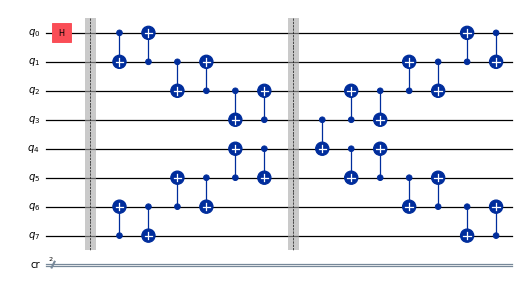

In [29]:
qc_uni.draw("mpl", fold=-1, scale=0.45)

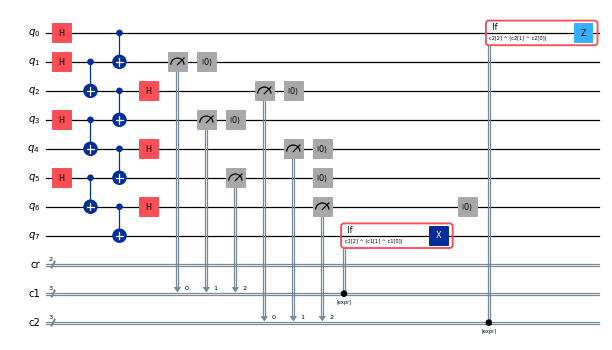

In [30]:
qc_dyn.draw("mpl", fold=-1, scale=0.45)

## 2. Fidelity metric

For each circuit we run three certification circuits, measuring `XX`, `YY`, and `ZZ` correlations on the two endpoint qubits. The reported value is the average gate fidelity

$$F_{avg} = \frac{4 F_{proc} + 1}{5}, \quad F_{proc}=\frac{1+\langle XX\rangle-\langle YY\rangle+\langle ZZ\rangle}{4}.$$

In [31]:
def _count_key_to_bits(count_key, width: int = 0) -> str:
    clean = str(count_key).replace(" ", "")
    if clean.startswith("0x"):
        clean = bin(int(clean, 16))[2:]
    else:
        clean = "".join(char for char in clean if char in "01")
    return clean.zfill(width)


def compute_endpoint_expectation(counts: dict) -> float:
    """Compute endpoint ZZ expectation after the requested basis rotation."""
    total = sum(counts.values())
    if total == 0:
        return 0.0

    max_width = max(len(_count_key_to_bits(key)) for key in counts)
    expectation = 0.0
    for key, count in counts.items():
        bits = _count_key_to_bits(key, width=max_width)
        # The first classical register `cr` is printed rightmost. Its bits are cr[1] cr[0].
        z_control = -1 if bits[-1] == "1" else 1
        z_target = -1 if bits[-2] == "1" else 1
        expectation += z_control * z_target * count
    return expectation / total


def compute_process_fidelity(counts_xx: dict, counts_yy: dict, counts_zz: dict) -> float:
    xx = compute_endpoint_expectation(counts_xx)
    yy = compute_endpoint_expectation(counts_yy)
    zz = compute_endpoint_expectation(counts_zz)
    return 0.25 * (1.0 + xx - yy + zz)


def compute_average_gate_fidelity(counts_xx: dict, counts_yy: dict, counts_zz: dict) -> float:
    f_proc = compute_process_fidelity(counts_xx, counts_yy, counts_zz)
    return (4.0 * f_proc + 1.0) / 5.0


def summarize_certification_counts(counts_by_basis: dict[str, dict]) -> dict[str, float]:
    xx = compute_endpoint_expectation(counts_by_basis["XX"])
    yy = compute_endpoint_expectation(counts_by_basis["YY"])
    zz = compute_endpoint_expectation(counts_by_basis["ZZ"])
    f_proc = 0.25 * (1.0 + xx - yy + zz)
    return {
        "xx": xx,
        "yy": yy,
        "zz": zz,
        "f_process": f_proc,
        "f_avg": (4.0 * f_proc + 1.0) / 5.0,
    }

## 3. Parameterized noise model

The noise model has three main knobs:

- `one_qubit_depol`, `two_qubit_depol`: depolarizing gate noise.
- `readout_error`: symmetric classical readout assignment error.
- `t1_us`, `t2_us`: thermal relaxation constants. Gate durations set how strongly this noise acts.

`reset_error` is kept because the dynamic circuit resets measured ancillas, matching the Problem 1 style.

In [32]:
@dataclass(frozen=True)
class NoiseParams:
    one_qubit_depol: float = 0.001
    two_qubit_depol: float = 0.01
    reset_error: float = 0.01
    readout_error: float = 0.02
    t1_us: float = 100.0
    t2_us: float = 80.0
    one_qubit_gate_time_ns: float = 50.0
    two_qubit_gate_time_ns: float = 300.0
    reset_time_ns: float = 1000.0
    include_depolarizing: bool = True
    include_readout: bool = True
    include_thermal: bool = True
    include_reset_error: bool = True


ONE_QUBIT_NOISY_GATES = ["id", "h", "x", "z", "s", "sdg", "sx"]
TWO_QUBIT_NOISY_GATES = ["cx"]


def _clip_probability(value: float, upper: float = 1.0) -> float:
    return min(max(float(value), 0.0), upper)


def _compose_quantum_errors(errors):
    errors = [error for error in errors if error is not None]
    if not errors:
        return None
    combined = errors[0]
    for error in errors[1:]:
        combined = combined.compose(error)
    return combined


def _thermal_1q(params: NoiseParams, gate_time_ns: float):
    t1_s = params.t1_us * 1e-6
    t2_s = min(params.t2_us * 1e-6, 2.0 * t1_s)
    gate_time_s = gate_time_ns * 1e-9
    return thermal_relaxation_error(t1_s, t2_s, gate_time_s)


def _thermal_nq(params: NoiseParams, num_qubits: int, gate_time_ns: float):
    thermal = _thermal_1q(params, gate_time_ns)
    combined = thermal
    for _ in range(num_qubits - 1):
        combined = combined.tensor(thermal)
    return combined


def build_lrcx_noise_model(params: NoiseParams) -> NoiseModel:
    """Build an Aer noise model from explicit scalar parameters."""
    noise_model = NoiseModel()

    one_qubit_errors = []
    two_qubit_errors = []

    if params.include_depolarizing:
        p1 = _clip_probability(params.one_qubit_depol)
        p2 = _clip_probability(params.two_qubit_depol)
        if p1 > 0:
            one_qubit_errors.append(depolarizing_error(p1, 1))
        if p2 > 0:
            two_qubit_errors.append(depolarizing_error(p2, 2))

    if params.include_thermal:
        one_qubit_errors.append(_thermal_nq(params, 1, params.one_qubit_gate_time_ns))
        two_qubit_errors.append(_thermal_nq(params, 2, params.two_qubit_gate_time_ns))

    one_qubit_error = _compose_quantum_errors(one_qubit_errors)
    two_qubit_error = _compose_quantum_errors(two_qubit_errors)

    if one_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(one_qubit_error, ONE_QUBIT_NOISY_GATES)
    if two_qubit_error is not None:
        noise_model.add_all_qubit_quantum_error(two_qubit_error, TWO_QUBIT_NOISY_GATES)

    reset_errors = []
    if params.include_reset_error:
        reset_p = _clip_probability(params.reset_error)
        if reset_p > 0:
            reset_errors.append(pauli_error([("X", reset_p), ("I", 1.0 - reset_p)]))
    if params.include_thermal:
        reset_errors.append(_thermal_nq(params, 1, params.reset_time_ns))
    reset_error = _compose_quantum_errors(reset_errors)
    if reset_error is not None:
        noise_model.add_all_qubit_quantum_error(reset_error, ["reset"])

    if params.include_readout:
        readout_p = _clip_probability(params.readout_error)
        readout_error = ReadoutError(
            [[1.0 - readout_p, readout_p], [readout_p, 1.0 - readout_p]]
        )
        noise_model.add_all_qubit_readout_error(readout_error)

    return noise_model


BASE_NOISE = NoiseParams()
build_lrcx_noise_model(BASE_NOISE)

<NoiseModel on ['cx', 'measure', 'h', 'x', 's', 'id', 'sx', 'sdg', 'z', 'reset']>

## 4. Run one noisy fidelity point

In [33]:
def make_simulator(noise_params: NoiseParams | None = None, seed: int = GLOBAL_SEED) -> AerSimulator:
    if noise_params is None:
        return AerSimulator(seed_simulator=seed)
    return AerSimulator(noise_model=build_lrcx_noise_model(noise_params), seed_simulator=seed)


def run_cnot_certification(
    distance: int,
    mode: str,
    noise_params: NoiseParams | None = None,
    shots: int = SHOTS,
    seed: int = GLOBAL_SEED,
) -> dict[str, float]:
    circuits = certification_circuits(distance, mode=mode)
    simulator = make_simulator(noise_params, seed=seed)
    # Do not transpile against the AerSimulator target here: its default
    # target is capped at 30 qubits, while the distance sweep uses up to
    # distance=40 (42 circuit qubits). Aer can execute these circuits directly.
    result = simulator.run(circuits, shots=shots).result()
    counts_by_basis = {
        basis: result.get_counts(index)
        for index, basis in enumerate(["XX", "YY", "ZZ"])
    }
    summary = summarize_certification_counts(counts_by_basis)
    summary.update(
        {
            "distance": distance,
            "variant": mode,
            "shots": shots,
            "num_qubits": distance + 2,
        }
    )
    return summary


single_point_rows = []
for variant in ["dynamic", "unitary"]:
    single_point_rows.append(
        run_cnot_certification(
            distance=DISTANCE_DEMO,
            mode=variant,
            noise_params=BASE_NOISE,
            shots=SHOTS,
        )
    )

pd.DataFrame(single_point_rows)

,xx,yy,zz,f_process,f_avg,distance,variant,shots,num_qubits
0,0.714844,-0.617188,0.699219,0.757812,0.806250,6,dynamic,512,8
1,0.695312,-0.644531,0.679688,0.754883,0.803906,6,unitary,512,8


## 5. Distance x noise-parameter sweeps

Use `sweep_distance_and_noise_parameter` for one scalar parameter at a time. `thermal_us` is a convenience knob that sets both `t1_us` and `t2_us` to the same value.

In [34]:
def noise_params_for_sweep_value(
    base_params: NoiseParams,
    parameter: str,
    value: float,
) -> NoiseParams:
    value = float(value)
    if parameter == "thermal_us":
        return replace(base_params, t1_us=value, t2_us=value)
    if parameter == "depolarizing_scale":
        return replace(
            base_params,
            one_qubit_depol=base_params.one_qubit_depol * value,
            two_qubit_depol=base_params.two_qubit_depol * value,
        )
    if not hasattr(base_params, parameter):
        raise ValueError(f"Unknown noise parameter: {parameter}")
    return replace(base_params, **{parameter: value})


def sweep_distance_and_noise_parameter(
    parameter: str,
    values,
    distances,
    base_params: NoiseParams = BASE_NOISE,
    variants=("dynamic", "unitary"),
    shots: int = SHOTS,
    seed: int = GLOBAL_SEED,
) -> pd.DataFrame:
    rows = []
    values = list(values)
    distances = list(distances)
    variants = tuple(variants)
    total = len(values) * len(distances) * len(variants)
    point = 0

    for value in values:
        params = noise_params_for_sweep_value(base_params, parameter, value)
        params_dict = asdict(params)
        for distance in distances:
            for variant in variants:
                point += 1
                result = run_cnot_certification(
                    distance=distance,
                    mode=variant,
                    noise_params=params,
                    shots=shots,
                    seed=seed + point,
                )
                result.update(params_dict)
                result.update(
                    {
                        "noise_parameter": parameter,
                        "noise_value": float(value),
                    }
                )
                rows.append(result)

                if point % max(1, total // 8) == 0 or point == total:
                    print(
                        f"{parameter}: {point}/{total} | "
                        f"value={value:g}, n={distance}, {variant}, "
                        f"F_avg={result['f_avg']:.4f}"
                    )

    return pd.DataFrame(rows)


DISTANCE_GRID = [1, 10, 20, 30, 40]
TWO_QUBIT_DEPOL_GRID = [0.0, 0.005, 0.01, 0.02]
READOUT_ERROR_GRID = [0.0, 0.01, 0.02, 0.05]
THERMAL_TIME_GRID_US = [40.0, 80.0, 120.0, 200.0]

print("distance grid:", DISTANCE_GRID)
print("two-qubit depolarizing grid:", TWO_QUBIT_DEPOL_GRID)
print("readout grid:", READOUT_ERROR_GRID)
print("thermal T1=T2 grid (us):", THERMAL_TIME_GRID_US)

distance grid: [1, 10, 20, 30, 40]
two-qubit depolarizing grid: [0.0, 0.005, 0.01, 0.02]
readout grid: [0.0, 0.01, 0.02, 0.05]
thermal T1=T2 grid (us): [40.0, 80.0, 120.0, 200.0]


In [35]:
# Run the three sweeps. Increase SHOTS or grid sizes above for final data.
sweep_results = {
    "two_qubit_depol": sweep_distance_and_noise_parameter(
        "two_qubit_depol",
        TWO_QUBIT_DEPOL_GRID,
        DISTANCE_GRID,
    ),
    "readout_error": sweep_distance_and_noise_parameter(
        "readout_error",
        READOUT_ERROR_GRID,
        DISTANCE_GRID,
    ),
    "thermal_us": sweep_distance_and_noise_parameter(
        "thermal_us",
        THERMAL_TIME_GRID_US,
        DISTANCE_GRID,
    ),
}

all_sweeps = pd.concat(sweep_results.values(), ignore_index=True)
all_sweeps.head()

two_qubit_depol: 5/40 | value=0, n=20, dynamic, F_avg=0.6906
two_qubit_depol: 10/40 | value=0, n=40, unitary, F_avg=0.7000
two_qubit_depol: 15/40 | value=0.005, n=20, dynamic, F_avg=0.6547
two_qubit_depol: 20/40 | value=0.005, n=40, unitary, F_avg=0.5320
two_qubit_depol: 25/40 | value=0.01, n=20, dynamic, F_avg=0.6281
two_qubit_depol: 30/40 | value=0.01, n=40, unitary, F_avg=0.4953
two_qubit_depol: 35/40 | value=0.02, n=20, dynamic, F_avg=0.5703
two_qubit_depol: 40/40 | value=0.02, n=40, unitary, F_avg=0.4203
readout_error: 5/40 | value=0, n=20, dynamic, F_avg=0.8047
readout_error: 10/40 | value=0, n=40, unitary, F_avg=0.5148
readout_error: 15/40 | value=0.01, n=20, dynamic, F_avg=0.7000
readout_error: 20/40 | value=0.01, n=40, unitary, F_avg=0.5055
readout_error: 25/40 | value=0.02, n=20, dynamic, F_avg=0.6281
readout_error: 30/40 | value=0.02, n=40, unitary, F_avg=0.4953
readout_error: 35/40 | value=0.05, n=20, dynamic, F_avg=0.4797
readout_error: 40/40 | value=0.05, n=40, unitary, F

,xx,yy,zz,f_process,f_avg,distance,variant,shots,num_qubits,one_qubit_depol,...,t2_us,one_qubit_gate_time_ns,two_qubit_gate_time_ns,reset_time_ns,include_depolarizing,include_readout,include_thermal,include_reset_error,noise_parameter,noise_value
0,0.859375,-0.867188,0.902344,0.907227,0.925781,1,dynamic,512,3,0.001,...,80.0,50.0,300.0,1000.0,True,True,True,True,two_qubit_depol,0.0
1,0.937500,-0.910156,0.921875,0.942383,0.953906,1,unitary,512,3,0.001,...,80.0,50.0,300.0,1000.0,True,True,True,True,two_qubit_depol,0.0
2,0.714844,-0.550781,0.722656,0.747070,0.797656,10,dynamic,512,12,0.001,...,80.0,50.0,300.0,1000.0,True,True,True,True,two_qubit_depol,0.0
3,0.777344,-0.734375,0.820312,0.833008,0.866406,10,unitary,512,12,0.001,...,80.0,50.0,300.0,1000.0,True,True,True,True,two_qubit_depol,0.0
4,0.542969,-0.320312,0.589844,0.613281,0.690625,20,dynamic,512,22,0.001,...,80.0,50.0,300.0,1000.0,True,True,True,True,two_qubit_depol,0.0


## 6. Plotting helpers

In [36]:
def plot_sweep_heatmaps(df: pd.DataFrame, title: str | None = None) -> None:
    parameter = df["noise_parameter"].iloc[0]
    title = title or parameter
    variants = list(df["variant"].drop_duplicates())

    fig, axes = plt.subplots(1, len(variants), figsize=(5.8 * len(variants), 4.5), squeeze=False)
    axes = axes.ravel()

    for ax, variant in zip(axes, variants):
        pivot = (
            df[df["variant"] == variant]
            .pivot_table(index="noise_value", columns="distance", values="f_avg", aggfunc="mean")
            .sort_index()
        )
        image = ax.imshow(pivot.values, origin="lower", aspect="auto", vmin=0.0, vmax=1.0)
        ax.set_title(f"{title} | {variant}")
        ax.set_xlabel("distance n")
        ax.set_ylabel(parameter)
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(x) for x in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([f"{x:g}" for x in pivot.index])
        ax.grid(False)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="F_avg")

    fig.tight_layout()
    plt.show()


def plot_sweep_lines(df: pd.DataFrame, title: str | None = None) -> None:
    parameter = df["noise_parameter"].iloc[0]
    title = title or parameter

    fig, ax = plt.subplots(figsize=(8, 5))
    for (variant, value), group in df.groupby(["variant", "noise_value"]):
        ordered = group.sort_values("distance")
        linestyle = "-" if variant == "dynamic" else "--"
        ax.plot(
            ordered["distance"],
            ordered["f_avg"],
            marker="o",
            linestyle=linestyle,
            label=f"{variant}, {parameter}={value:g}",
        )

    ax.set_title(title)
    ax.set_xlabel("distance n")
    ax.set_ylabel("Average gate fidelity F_avg")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

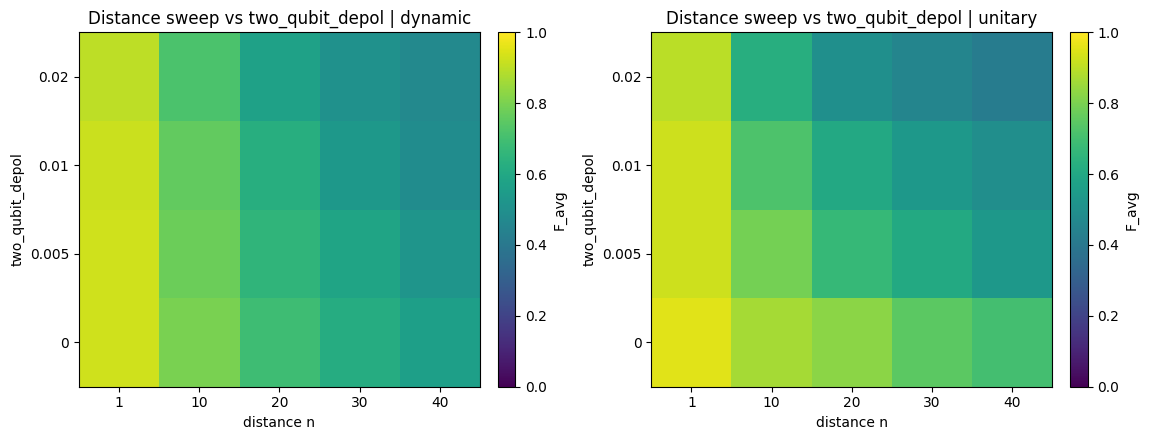

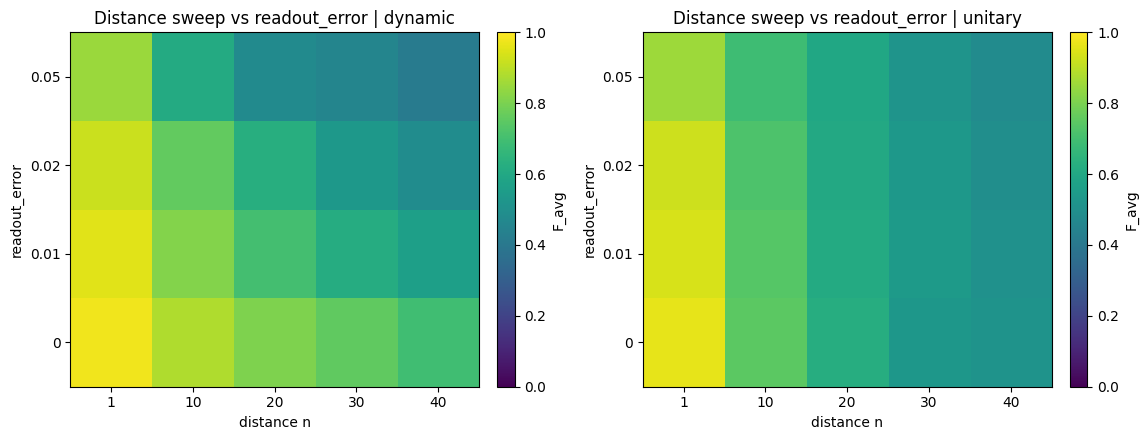

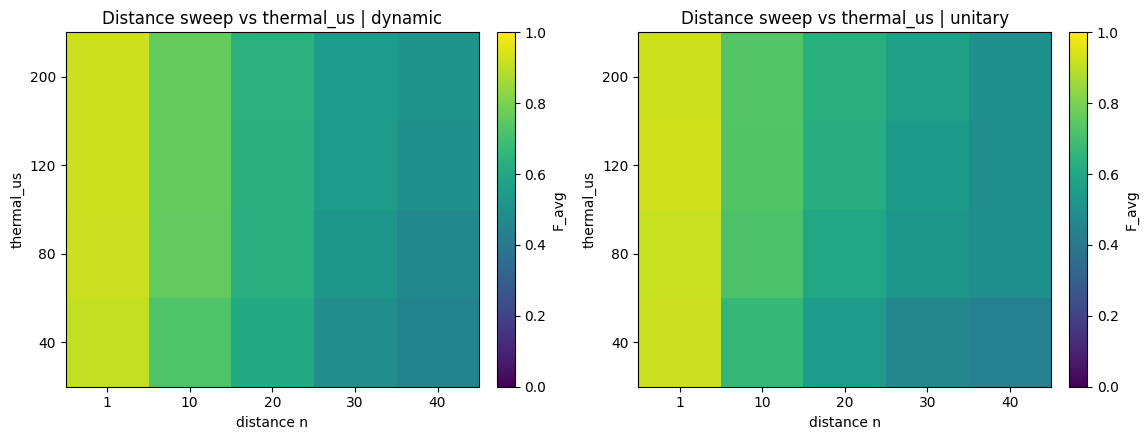

In [37]:
for parameter, df in sweep_results.items():
    plot_sweep_heatmaps(df, title=f"Distance sweep vs {parameter}")

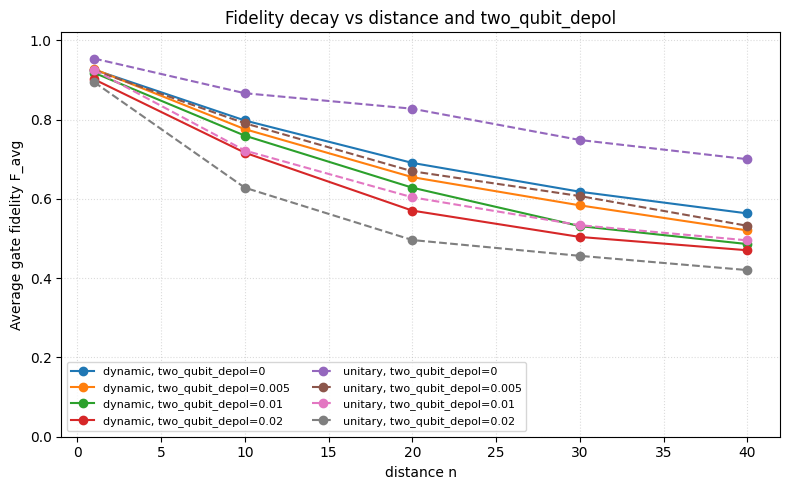

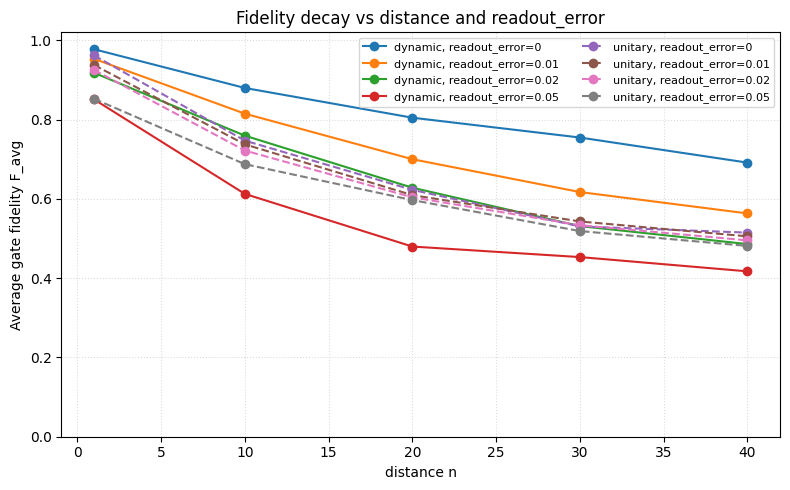

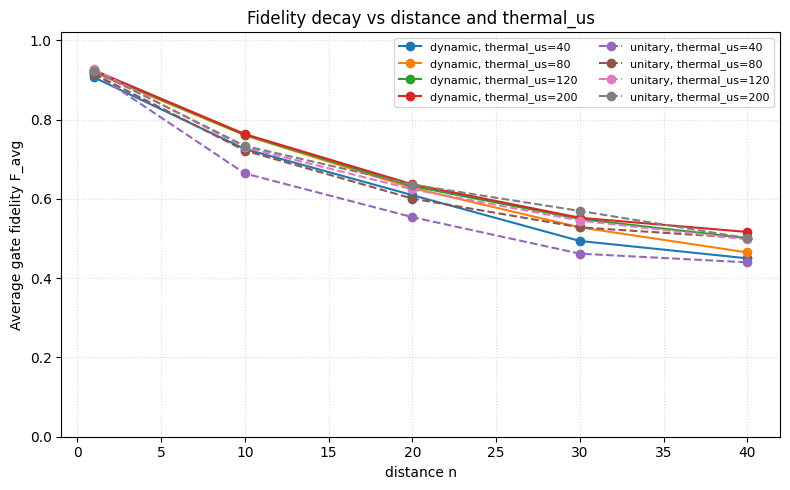

In [38]:
# Optional line plots for closer reading.
for parameter, df in sweep_results.items():
    plot_sweep_lines(df, title=f"Fidelity decay vs distance and {parameter}")

## 7. Compact summary tables

In [39]:
summary_table = (
    all_sweeps
    .groupby(["noise_parameter", "noise_value", "variant"], as_index=False)
    .agg(
        mean_f_avg=("f_avg", "mean"),
        min_f_avg=("f_avg", "min"),
        max_f_avg=("f_avg", "max"),
    )
)
summary_table

,noise_parameter,noise_value,variant,mean_f_avg,min_f_avg,max_f_avg
0,readout_error,0.000,dynamic,0.821562,0.691406,0.977344
1,readout_error,0.000,unitary,0.675312,0.514844,0.961719
2,readout_error,0.010,dynamic,0.729688,0.563281,0.953125
3,readout_error,0.010,unitary,0.666563,0.505469,0.937500
4,readout_error,0.020,dynamic,0.664531,0.485938,0.917969
5,readout_error,0.020,unitary,0.655938,0.495312,0.925000
6,readout_error,0.050,dynamic,0.562656,0.417187,0.850781
7,readout_error,0.050,unitary,0.627344,0.481250,0.852344
8,thermal_us,40.000,dynamic,0.637031,0.450000,0.906250
9,thermal_us,40.000,unitary,0.607500,0.439844,0.917969


In [40]:
# Save results if needed for the report.
# all_sweeps.to_csv("figures/p3_noise_distance_sweep.csv", index=False)